# Zadanie obowiązkowe [0-10] pkt

1. [0-1 pkt] Zaproponuj EDA po skalowaniu cech (tj. analiza macierzy zliczeń)
1. [0-2 pkt] Dostosuj parametry wektoryzacji (np. `ngram_range`, `min_df`, `max_df`) na podstawie analizy wyżej. Zrób wyszukiwanie po parametrach, używając `ROCAUC` jako miary (zob. [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html))
1. [0-1 pkt] Porównanj wyniki z rozkładem Bernoulliego. Zidentyfikuj przykłady, dla których każdy z modeli działa lepiej
1. [0-1.5 pkt] Użyj transformacji [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) zaraz po wektoryzacji dla rozkładu wielomianowego i Gaussowskiego. W tym celu użyj funkcjonalności `Pipeline`
   1. w przypadku rozkładu Gaussowskiego wymagane będzie użycia transformatora postaci gęstej macierzy (patrz kod niżej)
   1. Skomentuj, dlaczego model z rozkładem Gaussa działa gorzej
1. [0-1.5 pkt] Wytrenuj [regresję logistyczną](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), robiąc przeszukanie po hiperparametrach
1. [0-1 pkt] Porównaj krzywe kalibracyjne (użyj tego [API](https://scikit-learn.org/stable/modules/calibration.html)) dla obu modeli. Skomentuj wyniki
1. [0-2 pkt] Spróbuj znaleźć dwa reprezentatywne n-gramy, które najlepiej separują klasy. Wyrysuj obszary decyzyjne dla obu klasyfikatorów

```Python
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()
```

# 0. Import i wstępne przekształcenie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [3]:
sms = pd.read_csv('sms+spam+collection/SMSSpamCollection', 
                  delimiter='\t', header=None, names=['is_spam', 'text'])

# Zamiana spam i ham na 1 i 0
sms.loc[sms['is_spam'] == 'spam', 'is_spam'] = 1
sms.loc[sms['is_spam'] == 'ham', 'is_spam']  = 0
sms['is_spam']=  sms['is_spam'].astype('int8')

# Podział na wyjaśniającą i objaśnianą
X = sms['text']
y = sms['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=0)

### 1. EDA

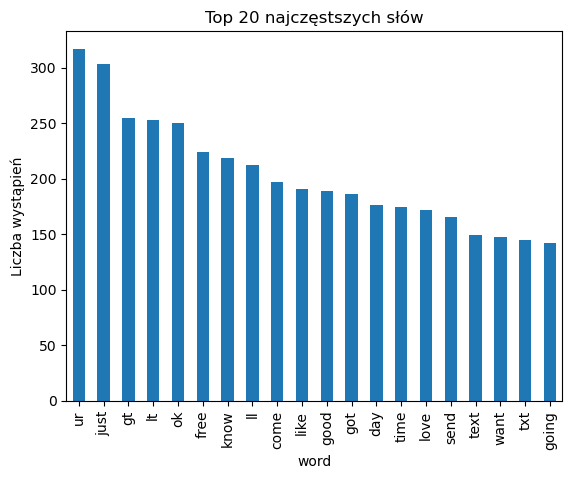

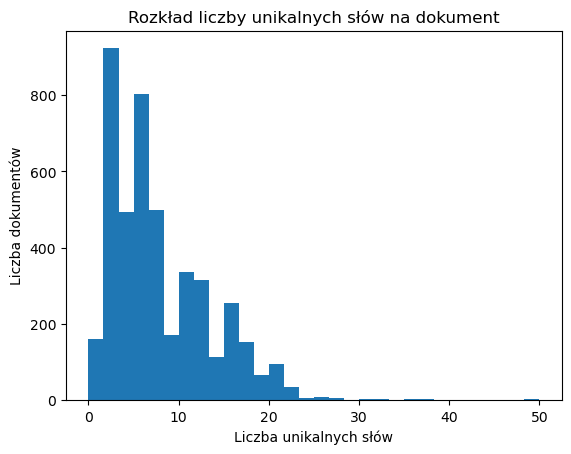

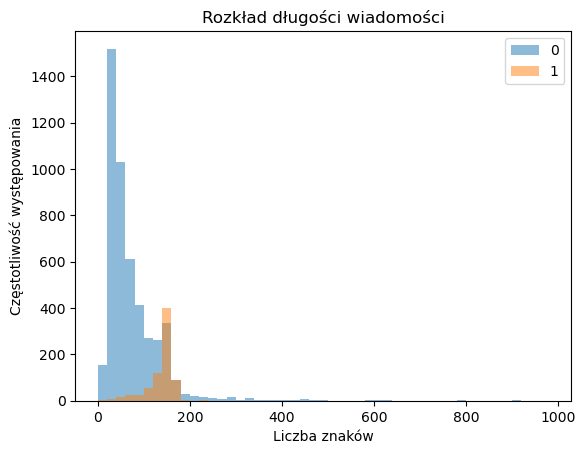

In [6]:
# Wektoryzacja tekstu
vect = CountVectorizer(stop_words='english')
X_train_counts = vect.fit_transform(X_train)

# Częstość
word_counts = np.asarray(X_train_counts.sum(axis=0)).flatten()
words = vect.get_feature_names_out()
word_freq = pd.DataFrame({'word': words, 'count': word_counts})
top_words = word_freq.sort_values(by='count', ascending=False).head(20)

# Liczba unikalnych słów na dokument
unique_words_per_doc = (X_train_counts > 0).sum(axis=1)
unique_words_per_doc = np.asarray(unique_words_per_doc).flatten()

# Wykresy
top_words.plot.bar(x='word', y='count', legend=False)
plt.title('Top 20 najczęstszych słów')
plt.ylabel('Liczba wystąpień')
plt.show()

plt.hist(unique_words_per_doc, bins=30)
plt.title('Rozkład liczby unikalnych słów na dokument')
plt.xlabel('Liczba unikalnych słów')
plt.ylabel('Liczba dokumentów')
plt.show()

for cat in sms['is_spam'].unique():
    sms[sms['is_spam'] == cat]['text'].str.len().plot(bins=np.arange(0, 1000, 20), 
                                                      kind='hist', label=cat, alpha=0.5)
plt.xlabel('Liczba znaków')
plt.ylabel('Częstotliwość występowania')
plt.title('Rozkład długości wiadomości')
plt.legend()

### 2. Parametry wektoryzacji

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('clf', MultinomialNB()) # Jako baseline użyjemy naiwnego klasyfikatora Bayesa z wielomianowym modelowaniem wiarygodności
])

param_grid = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__min_df': [1, 3, 5],
    'vect__max_df': [0.8, 0.9, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect',
                                        CountVectorizer(stop_words='english')),
                                       ('clf', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'vect__max_df': [0.8, 0.9, 1.0],
                         'vect__min_df': [1, 3, 5],
                         'vect__ngram_range': [(1, 1), (1, 2)]},
             scoring='roc_auc')

In [8]:
print("Najlepsze parametry:", grid.best_params_)
print(f"ROC AUC (CV): {grid.best_score_:.2f}")

Najlepsze parametry: {'vect__max_df': 0.8, 'vect__min_df': 3, 'vect__ngram_range': (1, 1)}
ROC AUC (CV): 0.99


### 3. Porównanie wyników: MultinomialNB vs BernoulliNB 

In [9]:
from sklearn.naive_bayes import BernoulliNB

# MultinomialNB (parametry z grid search)
best_vect = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=3, max_df=0.8)
X_train_vec = best_vect.fit_transform(X_train)
X_test_vec = best_vect.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)
y_pred_mnb = mnb.predict(X_test_vec)
y_prob_mnb = mnb.predict_proba(X_test_vec)[:, 1]

# Bernoulli (parametry z grid search)
bernoulli_vect = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=3, max_df=0.9, binary=True)
X_train_bin = bernoulli_vect.fit_transform(X_train)
X_test_bin = bernoulli_vect.transform(X_test)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
y_pred_bnb = bnb.predict(X_test_bin)
y_prob_bnb = bnb.predict_proba(X_test_bin)[:, 1]

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score

print(f"MultinomialNB accuracy: {accuracy_score(y_test, y_pred_mnb):.2f}")
print(f"MultinomialNB ROC AUC: {roc_auc_score(y_test, y_prob_mnb):.2f}\n")

print(f"BernoulliNB accuracy: {accuracy_score(y_test, y_pred_bnb):.2f}")
print(f"BernoulliNB ROC AUC: {roc_auc_score(y_test, y_prob_bnb):.2f}")

MultinomialNB accuracy: 0.97
MultinomialNB ROC AUC: 0.98

BernoulliNB accuracy: 0.97
BernoulliNB ROC AUC: 0.99


In [17]:
diff_mask = y_pred_mnb != y_pred_bnb

# Multinomial poprawnie, Bernoulli błędnie
mnb_better = (y_pred_mnb == y_test) & (y_pred_bnb != y_test)

# Bernoulli poprawnie, Multinomial błędnie
bnb_better = (y_pred_mnb != y_test) & (y_pred_bnb == y_test)

print(f"MultinomialNB lepszy w {mnb_better.sum()} przypadkach")
print(f"BernoulliNB lepszy w {bnb_better.sum()} przypadkach\n")

print(f"Przypadki, w których MultinomialNB lepszy: {X_test[mnb_better].values[:3]}\n")
print(f"Przypadki, w których BernoulliNB lepszy: {X_test[bnb_better].values[:3]}\n")

print(f"Średnia długość wiadomości, w których MultinomialNB lepszy: {round(X_test[mnb_better].str.len().mean())}")
print(f"Średnia długość wiadomości, w których BernoulliNB lepszy: {round(X_test[bnb_better].str.len().mean())}")

MultinomialNB lepszy w 20 przypadkach
BernoulliNB lepszy w 13 przypadkach

Przypadki, w których MultinomialNB lepszy: ['FreeMsg>FAV XMAS TONES!Reply REAL'
 'You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750'
 'Text BANNEDUK to 89555 to see! cost 150p textoperator g696ga 18+ XXX']

Przypadki, w których BernoulliNB lepszy: ['Total video converter free download type this in google search:)'
 'TheMob>Yo yo yo-Here comes a new selection of hot downloads for our members to get for FREE! Just click & open the next link sent to ur fone...'
 "These won't do. Have to move on to morphine"]

Średnia długość wiadomości, w których MultinomialNB lepszy: 105
Średnia długość wiadomości, w których BernoulliNB lepszy: 69


[KOMENTARZ] Wyniki accuracy i AUROC były dla obu klasyfikatorów podobne i wysokie. MultinomialNB wydaje się radzić sobie lepiej z dłużysz mi wiadomościami, bo wykorzystuje informację o liczbie wystąpień słów. BernoulliNB lepiej radzi sobie z krótkimi wiadomościami, bo jest bardziej czuły na konkretne słowa.

### 4. Transformacja TF-IDF

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.base import TransformerMixin

pipeline_mnb = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=3, max_df=0.8)),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB())
])

pipeline_mnb.fit(X_train, y_train)
y_pred_mnb_tfidf = pipeline_mnb.predict(X_test)

class DenseTransformer(TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray()

# GaussianNB wymaga gęstych macierzy
pipeline_gnb = Pipeline([
    ('vect', CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=3, max_df=0.8)),
    ('tfidf', TfidfTransformer()),
    ('to_dense', DenseTransformer()),
    ('clf', GaussianNB())
])

pipeline_gnb.fit(X_train, y_train)
y_pred_gnb = pipeline_gnb.predict(X_test)

print(f"MultinomialNB TF-IDF accuracy: {accuracy_score(y_test, y_pred_mnb_tfidf):.2f}")
print(f"GaussianNB TF-IDF accuracy: {accuracy_score(y_test, y_pred_gnb):.2f}")

MultinomialNB TF-IDF accuracy: 0.98
GaussianNB TF-IDF accuracy: 0.83


[KOMENTARZ] Model MultinomialNB poradził sobie tym razem znacznie lepiej. GaussianNB zakłada normalny rozkład cech, co jest nierealne do osiągnięcia przy danych testowych, których rozkład jest przeważnie niesymetryczny.

### 5. Regresja logistyczna

In [19]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000))
])

param_grid = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__min_df': [1, 3, 5],
    'vect__max_df': [0.8, 0.9, 1.0],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

grid = GridSearchCV(pipeline_lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect',
                                        CountVectorizer(stop_words='english')),
                                       ('tfidf', TfidfTransformer()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1, 10],
                         'clf__penalty': ['l1', 'l2'],
                         'vect__max_df': [0.8, 0.9, 1.0],
                         'vect__min_df': [1, 3, 5],
                         'vect__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy')

In [21]:
print("Najlepsze parametry:", grid.best_params_)

y_pred_lr = grid.predict(X_test)
print(f"Dokładność: {accuracy_score(y_test, y_pred_lr):.2f}")

Najlepsze parametry: {'clf__C': 10, 'clf__penalty': 'l2', 'vect__max_df': 0.8, 'vect__min_df': 5, 'vect__ngram_range': (1, 1)}
Dokładność: 0.98


### 6. Krzywe kalibracyjne

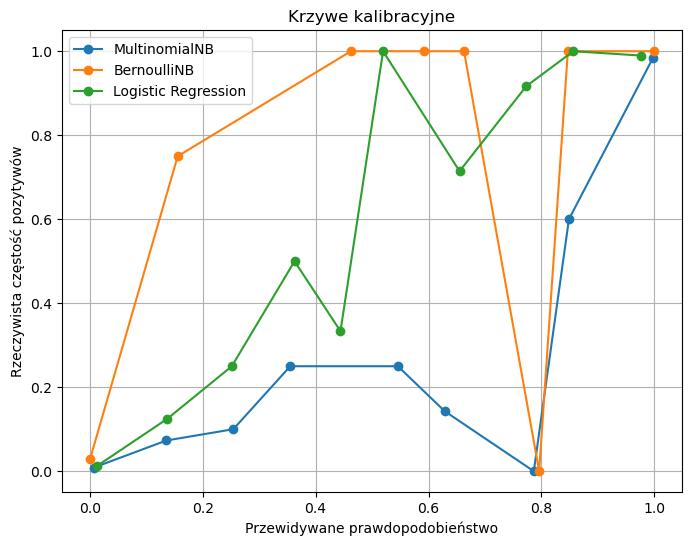

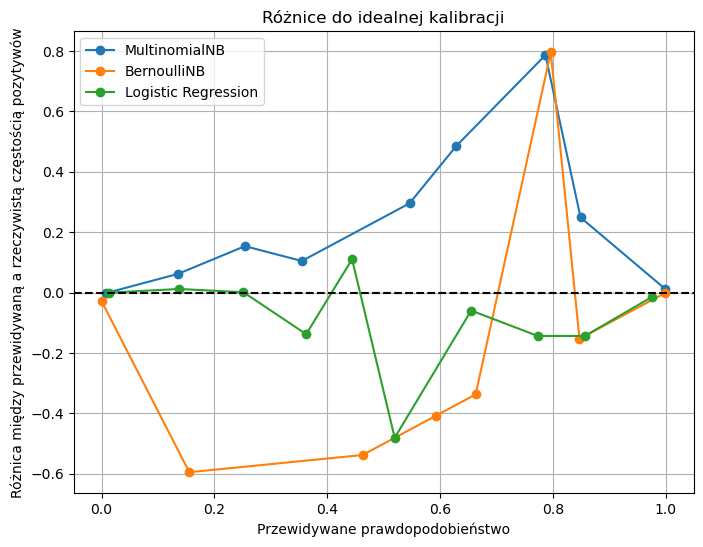

In [ ]:
from sklearn.calibration import calibration_curve

y_prob_lr = grid.predict_proba(X_test)[:, 1]

prob_true_mnb, prob_pred_mnb = calibration_curve(y_test, y_prob_mnb, n_bins=10, strategy='uniform')
prob_true_bnb, prob_pred_bnb = calibration_curve(y_test, y_prob_bnb, n_bins=10, strategy='uniform')
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10, strategy='uniform')

# Krzywe kalibracyjne
plt.figure(figsize=(8, 6))
plt.plot(prob_pred_mnb, prob_true_mnb, marker='o', label='MultinomialNB')
plt.plot(prob_pred_bnb, prob_true_bnb, marker='o', label='BernoulliNB')
plt.plot(prob_pred_lr, prob_true_lr, marker='o', label='Logistic Regression')
plt.xlabel('Przewidywane prawdopodobieństwo')
plt.ylabel('Rzeczywista częstość pozytywów')
plt.title('Krzywe kalibracyjne')
plt.legend()
plt.grid()
plt.show()

# Różnice do idelalnej kalibracji
plt.figure(figsize=(8, 6))
plt.plot(prob_pred_mnb, prob_pred_mnb - prob_true_mnb, marker='o', label='MultinomialNB')
plt.plot(prob_pred_bnb, prob_pred_bnb - prob_true_bnb, marker='o', label='BernoulliNB')
plt.plot(prob_pred_lr, prob_pred_lr - prob_true_lr, marker='o', label='Logistic Regression')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Przewidywane prawdopodobieństwo')
plt.ylabel('Różnica między przewidywaną a rzeczywistą częstością pozytywów')
plt.title('Różnice do idealnej kalibracji')
plt.legend()
plt.grid()
plt.show()

[KOMENTARZ] Najlepiej poradziła sobie regresja logistyczna, jej przewidywania były najlepiej skalibrowane. Pozostałe modele poradziły sobie gorzej.

### 7. Dwa najbardziej reprezentatywne n-gramy

In [28]:
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=3)
X_train_vec = vectorizer.fit_transform(X_train)
feature_names = np.array(vectorizer.get_feature_names_out())

# Podział na spam i ham
spam_mask = y_train == 1
ham_mask = y_train == 0

# Oblicz średnie występowanie każdego n-gramu w spamie i hamie
spam_freq = X_train_vec[spam_mask].mean(axis=0)
ham_freq = X_train_vec[ham_mask].mean(axis=0)

spam_freq = np.asarray(spam_freq).flatten()
ham_freq = np.asarray(ham_freq).flatten()

diff = spam_freq - ham_freq # dla kazdego n-gramu licze roznice

top_spam_ngram = feature_names[np.argmax(diff)]
top_ham_ngram = feature_names[np.argmin(diff)]

print(f"Najbardziej reprezentatywny n-gram dla SPAM: '{top_spam_ngram}'")
print(f"Najbardziej reprezentatywny n-gram dla HAM:  '{top_ham_ngram}'")

Najbardziej reprezentatywny n-gram dla SPAM: 'free'
Najbardziej reprezentatywny n-gram dla HAM:  'gt'


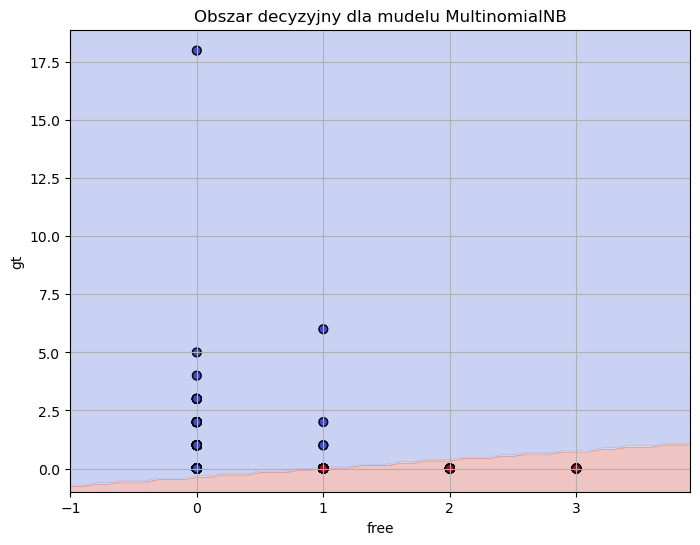

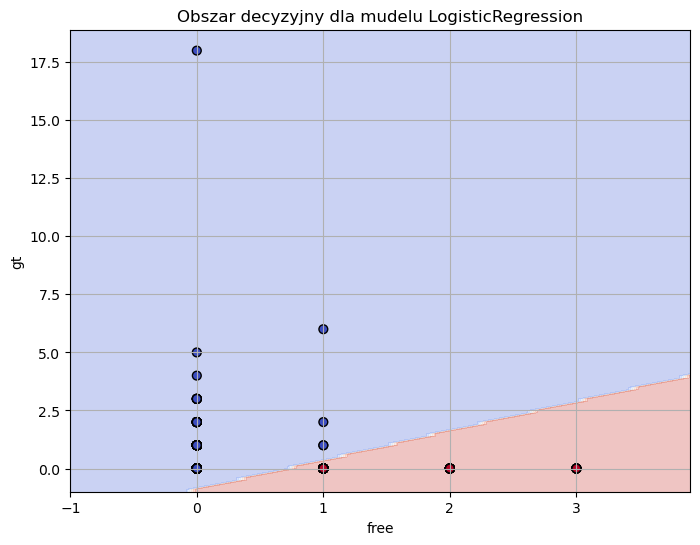

In [33]:
# Wybieramy tylko dwa n-gramy do wizualizacji i trenujamy na nich model
vect_2d = CountVectorizer(vocabulary=[top_spam_ngram, top_ham_ngram])
X_train_2d = vect_2d.fit_transform(X_train).toarray()
y_train_array = y_train.to_numpy()

def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel(top_spam_ngram)
    plt.ylabel(top_ham_ngram)
    plt.title(f"Obszar decyzyjny dla mudelu {model.__class__.__name__}")
    plt.grid(True)
    plt.show()

model = MultinomialNB()
model.fit(X_train_2d, y_train_array)
plot_decision_boundary(X_train_2d, y_train_array, model)

model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train_2d, y_train_array)
plot_decision_boundary(X_train_2d, y_train_array, model)

[KOMENTARZ] Te ngramy całkiem dobrze dzielą przestrzeń.

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Zaimplementuj [elastyczny naiwny klasyfikator Bayesa](https://arxiv.org/pdf/1302.4964) tj. NBC, w którym wiaygodność $p(x_i | y_k)$ jest modelowana osobno dla każdej klasy $k$ na podstawie [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) dla wszystkich punktów treningowych ($i=1\dots n$)
2. [0-1 pkt] Porównaj wyniki uzyskane za pomocą Gaussowskiego KDE dla różnych wartości parametru wygładzania ($h$, *smoothing*, *bandwidth*) z "globalnym" klasyfikatorem z rozkładem Gaussa (patrz zadanie obowiązkowe)

-